<div style="background-color: white; padding: 10px;">
<center>
    <img style="padding-left:15px"  height='50px' src="https://www.norkart.no/hubfs/norkart-logo-default.svg">
    <img style="padding-left:15px"  height='50px' src="https://www.kartverket.no/public/images/logo/kartverket-logo-large2.svg">
    <br />
    <img style="padding-right:15px" height='50px' src="https://kartai.no/wp-content/uploads/2025/03/cropped-KartAi-med-partnere-2048x1145.png">
    </center>
</div>

# ⛅ Cumulus Geographica - Lær hvordan bruke Cloud Native Geo (CNG)-teknologier? 🗺️

<a target="_blank" href="https://colab.research.google.com/github/kartAI/skygeo/blob/main/cumulus_geographica.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

------------
```
TODO
Hvordan unngår du hallusinering? Hvordan kan språkmodeller gjøre GIS-analyser?

Bli med på praktisk workshop der du lærer å kombinere kraften i moderne KI med geografiske data og analyser. I løpet av denne sesjonen vil du:

* Lære hvordan store språkmodeller (LLMs) kan transformere og effektivisere geografiske analyser
* Få hands-on erfaring med å koble ChatGPT-lignende modeller til PostGIS-databaser
* Utforske hvordan du kan stille komplekse geografiske spørsmål på naturlig språk
* Bygge interaktive kart og visualiseringer styrt av AI

Workshopen er designet for både nybegynnere og erfarne geomatikere som ønsker å utforske fremtidens analyseverktøy. Ta med laptop og bli med på å utforske der kunstig intelligens møter geografisk intelligens!

Ingen tidligere KI-erfaring nødvendig – bare ta med din geomatikkunnskap, laptop og god porsjon nysgjerrighet!
```
-------------




# Cumulus Geographica

**???**
* setup - duckdb, s3, httpfs, spatial
    * Forklaring på hva duckdb er??
    * Forklaring på hva geopandas er??
    * Linker til docs for duckdb??

**hvordan jobbe på datasett med milliarder av datapunkter effektivt?**
* Lakehouse-introduksjon - markdown
    * Overture Maps som eksempel
    * Andre åpne kilder? source.coop? Canada?
* Hente filtrerte places og bygninger fra OM - lagre som parquet og som tabeller. Poeng: Vi jobber på datasett med flere milliarder datapunkter og terabyte størrelser. 

**Hva med data som ikke er så store?**
* Bruke geopandas for å laste inn og gjøre analyser mellom kommuner og fylker
    * Hente fra Håvard sitt eksempel
    * Går fint når alt passer i RAM

**Større enn RAM => duckdb**
* Bruke duckdb for å filtrere kun 1 kommune fra parquet-url
* Bruke duckdb for å lage buffer på kommunepolygon. Finne bbox. 
* Filtrere bygninger og places med buffer-bbox med duckdb deretter nøyaktig spatial intersect.

**Refleksjonsspørsmål**
- Hvordan bør norske kartdata organiseres for effektiv bruk?
- Når bør du bruke geopandas? Når bør du bruke duckdb?

**Tips og tricks!**
* Hvordan lage duckdb-sql med agenter og KI?
    * instructions-eksempel



#### ⚙️ Konfigurasjon og oppsett
Kjør cellene under.

In [79]:
%%capture

%pip install dotenv geopandas folium matplotlib mapclassify duckdb

import os
import geopandas as gpd
import duckdb
from shapely import wkb
from pathlib import Path
from lonboard import Map, PathLayer, viz

kommuner_path = "https://kartaistorage.blob.core.windows.net/skygeo/workshopdata/kommuner_n1000.parquet"
kirkebygg_path = "https://kartaistorage.blob.core.windows.net/skygeo/workshopdata/kirkebygg_forenklet.parquet"


#### ⛅ Hva er Cloud Native Geo-teknologi?

* GeoParquet
* Hive-partitioning `*` er magien!
* OvertureMaps som eksempel
* Linker til mer ressurser helt

In [3]:
# setup duckdb connection
# Initialize DuckDB connection
conn = duckdb.connect(':memory:')

#install spatial
conn.execute("INSTALL spatial;")

# Load spatial extension
conn.execute("LOAD spatial;")

# Set S3 region for Overture Maps
conn.execute("SET s3_region='us-west-2';")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#### Kick the tires! 

Nå skal du prøve ut datauthenting fra OvertureMaps

1. Kjør cellen under
1. Se på dataschemaet ... http://....
- https://docs.overturemaps.org/theme-definitions-table.html
- https://docs.overturemaps.org/guides/places/
- https://github.com/OvertureMaps/schema/blob/main/docs/schema/concepts/by-theme/places/overture_categories.csv


1. Kan du hente ut kun ....


In [65]:

bbox_kristiansand = [7.875366,58.081425,8.099899,58.206042]
bbox = bbox_kristiansand
# Query pizza restaurants in Kristiansand from Overture Maps


query = f"""
SELECT
    id,
    names.primary as name,
    confidence,
    categories.primary as category,
    CAST(categories as JSON) as categories,
    CAST(socials AS JSON) as socials,
    geometry
FROM
    read_parquet('s3://overturemaps-us-west-2/release/2026-02-18.0/theme=places/type=place/*', 
                 filename=true, hive_partitioning=1)
WHERE
    categories.primary IN ('pizza_restaurant','pizza_delivery_service')
    AND bbox.xmin BETWEEN {bbox[0]} AND {bbox[2]}
    AND bbox.ymin BETWEEN {bbox[1]} AND {bbox[3]}
"""

# Execute query
result = conn.sql(query)

display(result.df())


,id,name,confidence,category,categories,socials,geometry
0,bdc1c5bd-b924-448f-b72e-b903293bdeff,Happy Time Møvig,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/470935122760751""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
1,f3b176c9-1494-4552-a8e7-39515642f796,Pizza Show Vågsbygd,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/310729392892191""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,dfd50477-1f9d-44c8-8f90-0463f6675b7c,Domino's,0.400000,pizza_delivery_service,"{""primary"":""pizza_delivery_service"",""alternate...",None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
3,fdee4f58-a433-48bf-88b8-1245e2a0a607,Domino's Pizza,1.000000,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":null}",None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
4,87b99033-b5ad-4d57-8263-0d0f74cdefa4,Pizzabakeren,0.970038,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""fa...","[""https://www.facebook.com/128311913852001""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
5,d40e5b20-7b6f-4e10-b169-ba01846fbb07,Every Day Pizza & Gyros,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/397846736749587""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
6,a209749f-350c-4077-8499-ad572d0005d6,Banda Santi,0.570194,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":null}","[""https://www.facebook.com/560995553771926""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
7,fe8fa4e8-1ff7-4958-bd5d-905d11d46823,Pizzabakeren Grim,0.970038,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""fa...","[""https://www.facebook.com/307286352784376""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
8,264df190-9378-43df-9479-e091e7132ba9,Kvadraturen grill & kiosk,0.639236,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/471456249716446""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
9,ea41d8dc-0f6e-44f1-92f7-85a5a641fa1b,Pizzeria,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":null}","[""https://www.facebook.com/338808489493076""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


In [58]:
viz(result)

c:\Users\alenos\anaconda3\envs\geo_env\Lib\site-packages\lonboard\_geoarrow\ops\reproject.py:40: UserWarning: No CRS exists on data. If no data is shown on the map, double check that your CRS is WGS84.
  warn(


In [66]:
# export the duckdb result to a parquet file and read it with geopandas
tmp_parquet_path = ".\\tmp\\duckdb_result.parquet"
result.to_parquet(tmp_parquet_path)

# read the parquet file with geopandas and visualize it
gdf = gpd.read_parquet(tmp_parquet_path)
gdf.head()
#result_df = pd.read_parquet(duckdb_path)
#display(result_df)
#result_df['geometry_wkb'] = result_df['geometry_wkb'].apply(lambda x: wkb.loads(x))
#gdf = gpd.GeoDataFrame(result_df, geometry='geometry_wkb')
#viz(gdf)

,id,name,confidence,category,categories,socials,geometry
0,bdc1c5bd-b924-448f-b72e-b903293bdeff,Happy Time Møvig,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/470935122760751""]",POINT (7.96458 58.11)
1,f3b176c9-1494-4552-a8e7-39515642f796,Pizza Show Vågsbygd,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/310729392892191""]",POINT (7.95948 58.11982)
2,dfd50477-1f9d-44c8-8f90-0463f6675b7c,Domino's,0.400000,pizza_delivery_service,"{""primary"":""pizza_delivery_service"",""alternate...",None,POINT (7.9565 58.1218)
3,fdee4f58-a433-48bf-88b8-1245e2a0a607,Domino's Pizza,1.000000,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":null}",None,POINT (7.95879 58.12476)
4,87b99033-b5ad-4d57-8263-0d0f74cdefa4,Pizzabakeren,0.970038,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""fa...","[""https://www.facebook.com/128311913852001""]",POINT (7.96079 58.12454)


#### Visualiser med GeoPandas

- .plot() = "matematisk" plotting
- .explore() = interaktivt kart

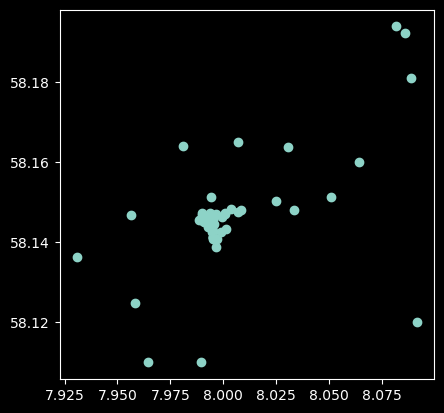

In [38]:
gdf.plot()
gdf.explore()

#### Lagre resultatet av en spørring som en tabell

In [67]:

conn.sql(f"""
CREATE OR REPLACE TABLE overturemap_results AS
    {query}
""")

conn.sql("SELECT * FROM overturemap_results").df().head(5)

,id,name,confidence,category,categories,socials,geometry
0,bdc1c5bd-b924-448f-b72e-b903293bdeff,Happy Time Møvig,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/470935122760751""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
1,f3b176c9-1494-4552-a8e7-39515642f796,Pizza Show Vågsbygd,0.950063,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""re...","[""https://www.facebook.com/310729392892191""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,dfd50477-1f9d-44c8-8f90-0463f6675b7c,Domino's,0.400000,pizza_delivery_service,"{""primary"":""pizza_delivery_service"",""alternate...",None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
3,fdee4f58-a433-48bf-88b8-1245e2a0a607,Domino's Pizza,1.000000,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":null}",None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
4,87b99033-b5ad-4d57-8263-0d0f74cdefa4,Pizzabakeren,0.970038,pizza_restaurant,"{""primary"":""pizza_restaurant"",""alternate"":[""fa...","[""https://www.facebook.com/128311913852001""]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


In [62]:
# Verify the geometry column exists and its type
r = conn.sql("DESCRIBE overturemap_results")
r.df()
# Or query just the column info
#conn.sql("SELECT column_name, data_type FROM information_schema.columns WHERE table_name='pizza_restaurants'").show()

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,name,VARCHAR,YES,None,None,None
2,confidence,DOUBLE,YES,None,None,None
3,category,VARCHAR,YES,None,None,None
4,categories,JSON,YES,None,None,None
5,socials,JSON,YES,None,None,None
6,geometry,GEOMETRY,YES,None,None,None


In [70]:
### Prøv andre temadata fra Overture Maps, for eksempel "buildings" eller "landuse", og visualiser resultatene i Geographica.

## Lag en ny tabell med bygninger fra overture maps innenfor din valgte bounding box
conn.sql(f"""
    CREATE OR REPLACE TABLE overturemap_buildings AS
        SELECT
            id,
            CAST(sources as JSON) as sources,
            subtype,
            geometry
        FROM
            read_parquet('s3://overturemaps-us-west-2/release/2026-02-18.0/theme=buildings/type=building/*', 
                        filename=true, hive_partitioning=1)
        WHERE
            bbox.xmin BETWEEN {bbox[0]} AND {bbox[2]}
            AND bbox.ymin BETWEEN {bbox[1]} AND {bbox[3]}
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#### Se litt på bygningsdataene

In [ ]:
# Hent ut og vis de første radene av bygningstabellen, og inkluder geometrien som WKT for å verifisere at den er korrekt lastet inn.
## LEGG merke til EXCLUDE syntaksen i DuckDB!!
conn.sql("SELECT * EXCLUDE geometry, st_astext(geometry) as geometry_wkt FROM overturemap_buildings").df().head(5)

,id,sources,subtype,geometry_wkt
0,67fa7b12-89ad-449d-9ae5-b340751aedc6,"[{""property"":"""",""dataset"":""OpenStreetMap"",""lic...",service,"POLYGON ((7.885485 58.0831121, 7.8853765 58.08..."
1,4842473c-aef4-4593-8263-6167f15ac5bf,"[{""property"":"""",""dataset"":""OpenStreetMap"",""lic...",residential,"POLYGON ((7.885738 58.083585, 7.885705 58.0835..."
2,0630bff8-ef5a-4298-83fa-06d7f40e7bee,"[{""property"":"""",""dataset"":""OpenStreetMap"",""lic...",residential,"POLYGON ((7.885815 58.083607, 7.885803 58.0835..."
3,c1feddf3-de3a-426b-8237-1775f98deeaf,"[{""property"":"""",""dataset"":""OpenStreetMap"",""lic...",residential,"POLYGON ((7.885788 58.0835157, 7.885734 58.083..."
4,3ed220bc-154b-42db-956b-f7f5743dd5e3,"[{""property"":"""",""dataset"":""Microsoft ML Buildi...",None,"POLYGON ((7.9066025 58.0826078, 7.9066317 58.0..."


In [76]:
conn.sql("SELECT  subtype, count(*) FROM overturemap_buildings GROUP BY subtype").df()

,subtype,count_star()
0,education,290
1,residential,31081
2,outbuilding,1837
3,commercial,1050
4,entertainment,21
5,medical,15
6,civic,234
7,religious,63
8,service,621
9,None,3935


#### Last inn norske kartdata
- kommunepolygoner
- kirkebygg forenklet

In [80]:
### Laster inn alle kommunepolygoner fra geoparquet

conn.sql(f"""
    CREATE OR REPLACE TABLE kommuner AS
        SELECT * FROM read_parquet('{kommuner_path}')
""")

conn.sql(f"""
    CREATE OR REPLACE TABLE kirkebygg AS
        SELECT * FROM read_parquet('{kirkebygg_path}')
""")

In [ ]:
## Valgfritt: Exploration and visualization

res = conn.sql("SELECT * FROM kirkebygg")
#res = conn.sql("SELECT * FROM kommuner")
viz(res)

#### Filtreringer og analyser

- Finn største bygning i areal
- Hvilken kirke har størst kapasitet i en bestemt kommune?
- Finn største bygning i areal i en bestemt kommune

Kjør cellene under

In [ ]:
# Hent inn kommunepolygon for 1 kommune eller flere kommuner

Bruk kommunepolygon som filtrering videre!

In [ ]:
# bbox-filter fra kommunepolygon - deretter spatial filter med st_intersects



In [ ]:
# Hent ut alle flomsoner i kommunen

In [ ]:
# Hent ut alle kirkebygg i kommunen med buffer 10 km

#buffer 10 km - plot. 
## bbox og spatial filter - execute

In [ ]:
# Kun kirkebygg utenfor flomsone og med kapasitet over 100 personer

In [ ]:
#Export csv, tabell og plotkart + html-kart til disk